# Qwen2-VL을 이용한 이미지 이해 실습

### 실습 목표
- **LVLM(Large Vision-Language Model)** 이 무엇인지 이해합니다
- **Qwen2-VL-2B-Instruct** 모델을 Colab에서 직접 불러와 실행해봅니다
- 이미지를 입력으로 주고 모델이 이미지를 어떻게 이해하는지 확인합니다
- 텍스트 질문과 이미지를 함께 넣어 **Visual Question Answering(VQA)** 을 경험합니다

### Contents
1. 환경 설정
2. LVLM이란 무엇인가?
3. Qwen2-VL 모델 불러오기
4. 이미지 설명 생성 (Image Captioning)
5. 이미지 질의응답 (Visual Question Answering)
6. 자유 실습


## 0. 환경 설정

> ⚠️ 반드시 **런타임 > 런타임 유형 변경 > GPU** 로 설정한 후 실습을 진행하세요.

필요한 라이브러리를 설치합니다.

| 라이브러리 | 역할 |
|---|---|
| `transformers` | Hugging Face 모델 로딩 라이브러리 |
| `Pillow` | 이미지 불러오기 및 처리 |
| `requests` | 인터넷에서 이미지 다운로드 |
| `accelerate` | GPU 메모리 효율적 사용 |
| `qwen-vl-utils` | Qwen2-VL 전용 유틸리티 |


In [1]:
# 필요한 라이브러리 설치
!pip install -q transformers Pillow requests accelerate qwen-vl-utils


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 38.8 MB/s eta 0:00:00


In [2]:
# 라이브러리 불러오기
import torch
import requests
from PIL import Image
from io import BytesIO
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

# GPU / CPU 자동 설정
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"사용 디바이스: {DEVICE}")


사용 디바이스: cuda


## 1. LVLM이란 무엇인가?

**LVLM(Large Vision-Language Model)** 은 **텍스트와 이미지를 동시에 이해**할 수 있는 대형 AI 모델입니다.

기존 언어 모델(GPT 등)은 텍스트만 처리할 수 있었지만,  
LVLM은 **이미지 + 텍스트**를 함께 입력받아 질문에 답하거나 이미지를 설명할 수 있습니다.

```
입력:  [이미지] + "이 이미지에서 무엇이 보이나요?"
출력:  "이미지에는 고양이 한 마리가 소파 위에 앉아 있습니다."
```

---

### 오늘 사용할 모델: Qwen2-VL-2B-Instruct

| 항목 | 내용 |
|---|---|
| 개발사 | Alibaba (알리바바) |
| 파라미터 수 | 약 2B (20억) |
| 특징 | 이미지 + 텍스트 동시 처리, 한국어 부분 지원 |
| Colab 무료 GPU | ✅ 사용 가능 (VRAM ~4GB) |

2B 모델은 가볍기 때문에 Colab 무료 환경(T4 GPU)에서도 안정적으로 동작합니다.


## 2. Qwen2-VL 모델 불러오기

GPT2에서 `GPT2Tokenizer`와 `GPT2LMHeadModel`을 각각 불러왔던 것처럼,  
Qwen2-VL도 **Processor**와 **Model**을 각각 불러옵니다.

| 구성요소 | 역할 |
|---|---|
| `AutoProcessor` | 이미지와 텍스트를 모델 입력 형태로 변환 (Tokenizer + 이미지 전처리 통합) |
| `Qwen2VLForConditionalGeneration` | 이미지 + 텍스트를 입력받아 텍스트를 생성하는 모델 |

> 💡 처음 실행 시 모델 파일을 다운로드하기 때문에 **1~3분** 정도 소요됩니다.


In [3]:
# ✅ 1. 모델과 Processor 불러오기
model_name = "Qwen/Qwen2-VL-2B-Instruct"

print("Processor 불러오는 중...")
processor = AutoProcessor.from_pretrained(model_name)

print("모델 불러오는 중... (1~3분 소요)")
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype=torch.float16,   # 메모리 절약을 위해 16-bit 사용
    device_map="auto"            # GPU/CPU 자동 배치
)
model.eval()

print("\n✅ 모델 로딩 완료!")
print(f"모델 파라미터 수: {sum(p.numel() for p in model.parameters()) / 1e9:.1f}B")


Processor 불러오는 중...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]


✅ 모델 로딩 완료!
모델 파라미터 수: 2.2B


## 3. 이미지 불러오기

실습에 사용할 이미지를 인터넷에서 불러옵니다.  
URL 주소만 바꾸면 원하는 이미지를 사용할 수 있습니다.


Saving 농협발표용사진.jpg to 농협발표용사진 (1).jpg
파일명: 농협발표용사진 (1).jpg
이미지 크기: (192, 263)  (가로 x 세로)


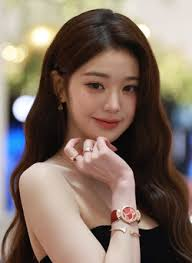

In [12]:
# ✅ 2. 이미지 업로드
from google.colab import files
from IPython.display import display

uploaded = files.upload()  # 파일 선택 창이 뜹니다

# 업로드된 첫 번째 이미지 불러오기
filename = list(uploaded.keys())[0]
image = Image.open(filename).convert("RGB")

# 이미지 크기 확인 및 시각화
print(f"파일명: {filename}")
print(f"이미지 크기: {image.size}  (가로 x 세로)")
display(image)


## 4. 이미지 설명 생성 (Image Captioning)

이미지를 입력으로 주고, 모델이 이미지를 설명하도록 합니다.

### 동작 흐름

```
[이미지] + [텍스트 질문]
   ↓
Processor (이미지 + 텍스트를 모델 입력 형태로 변환)
   ↓
Qwen2-VL 모델
   ↓
생성된 텍스트 답변
```


In [13]:
# ✅ 3. 이미지 설명 생성 함수 정의
def generate_response(image, question, max_new_tokens=256):
    """
    image        : PIL Image 객체
    question     : 모델에게 물어볼 질문 (텍스트)
    max_new_tokens: 생성할 최대 토큰 수
    """
    # 메시지 형식 구성 (Qwen2-VL 형식)
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text",  "text":  question},
            ],
        }
    ]

    # Processor로 입력 준비
    text_input = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text_input],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(DEVICE)

    # 모델로 텍스트 생성
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens
        )

    # 입력 부분 제거 후 디코딩
    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )

    return output_text[0]

print("✅ 함수 정의 완료!")


✅ 함수 정의 완료!


In [15]:
# ✅ 4. 이미지 설명 생성 (Image Captioning)
question = "Describe the image in detail"

print(f"질문: {question}")
print("모델 응답 생성 중...")
print("-" * 50)

response = generate_response(image, question)
print(response)


질문: Describe the image in detail
모델 응답 생성 중...
--------------------------------------------------
The image shows a person with long, wavy hair that cascades down their back. They are wearing a black top and a red watch with a floral design on the face. The watch has a small, round face and a gold band. The person is also wearing small, dangling earrings. The background appears to be an indoor setting with a blurred, possibly reflective surface, suggesting a well-lit environment.


## 5. 이미지 질의응답 (Visual Question Answering)

이미지에 대해 구체적인 질문을 던지고 답변을 받아봅니다.  
아래 셀을 하나씩 실행하면서 결과를 확인해보세요.


In [8]:
# ✅ 5. VQA - 특정 사물 묻기
question = "What are people doing in this image?"

print(f"질문: {question}")
print("-" * 50)
print(generate_response(image, question))


질문: What are people doing in this image?
--------------------------------------------------
In the image, a person is posing with their hand resting on their chin. They are wearing a black top and a watch with a red face. The background appears to be an indoor setting with some decorations.


In [9]:
# ✅ 6. VQA - 장소 파악하기
question = "Where do you think this photo was taken? Give me specific clues."

print(f"질문: {question}")
print("-" * 50)
print(generate_response(image, question))


질문: Where do you think this photo was taken? Give me specific clues.
--------------------------------------------------
The photo appears to have been taken at a fashion event or a high-end retail store. Here are some specific clues that suggest this:

1. **Background**: The background is well-lit and features a modern, elegant setting, which is typical of fashion events or high-end retail environments.
2. **Attire**: The person in the photo is wearing a black dress, which is commonly seen at fashion shows or upscale retail events.
3. **Accessories**: The person is wearing a watch with a red face, which is a common accessory at high-end fashion events.
4. **Lighting**: The lighting is bright and well-controlled, which is typical of professional photography used in fashion events or retail settings.

These clues suggest that the photo was taken at a fashion event or a high-end retail store.


In [10]:
# ✅ 7. VQA - 색상 묻기
question = "What colors are most prominent in this image?"

print(f"질문: {question}")
print("-" * 50)
print(generate_response(image, question))


질문: What colors are most prominent in this image?
--------------------------------------------------
The most prominent colors in this image are red and black.


In [16]:
# ✅ 8. VQA - 감정/분위기 파악
question = "How would you describe the atmosphere or mood of this scene?"

print(f"질문: {question}")
print("-" * 50)
print(generate_response(image, question))


질문: How would you describe the atmosphere or mood of this scene?
--------------------------------------------------
The scene appears to be well-lit and professional, suggesting that it might be a formal event or a photoshoot. The woman's attire and the background elements indicate that she is in a setting that requires a polished and sophisticated appearance. The overall mood is formal and elegant.


## 6. 자유 실습 🚀

이미지 URL과 질문을 자유롭게 바꿔보세요!

### 이미지 예시

| 주제 | URL |
|---|---|
| 고양이 | `https://upload.wikimedia.org/wikipedia/commons/thumb/1/18/Dog_Breeds.jpg/1200px-Dog_Breeds.jpg` |
| 음식 | `https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg` |
| 자연 | 원하는 이미지의 URL을 붙여넣기 |

### 질문 예시

- `"What objects can you see in this image?"`
- `"Is there any text visible? If so, what does it say?"`
- `"Count the number of people in the image."`
- `"What time of day does this appear to be?"`


In [18]:
# ✅ [자유 실습] 이미지를 업로드하고 질문을 바꿔보세요!

from google.colab import files

# ── 질문을 수정하세요 ──────────────────────────────────────
MY_QUESTION = "What is the most interesting thing about this image?"
# ──────────────────────────────────────────────────────────

# 이미지 업로드
uploaded = files.upload()
filename = list(uploaded.keys())[0]
my_image = Image.open(filename).convert("RGB")

print(f"파일명: {filename}")
print(f"이미지 크기: {my_image.size}")
display(my_image)

# 모델 응답 생성
print(f"\n질문: {MY_QUESTION}")
print("-" * 50)
print(generate_response(my_image, MY_QUESTION))


Output hidden; open in https://colab.research.google.com to view.